# 03. Meta cell AnnData

The [previous section](../embedding_and_meta_cell/02_meta_cell.ipynb) assigned every cell to a
**metacell** — a small, homogeneous SEACells group. This page pools the single cells of each
metacell into compact per-metacell **AnnData** objects that summarize the dataset at metacell
resolution: the tables Bolero uses for pseudobulk construction, evaluation, and its RNA head.

Using **ChromiumPBMC** (a 10x Multiome PBMC dataset) as the worked example, we build three files:

1. **Metadata & coordinates** — one row per metacell, with aggregated cell metadata and a
   representative embedding / UMAP coordinate.
2. **ATAC peak counts** — metacell × peak accessibility, summed from single cells.
3. **RNA gene counts** — metacell × gene expression, summed from single cells.

> **Where the data comes from.** The single-cell RNA / ATAC counts are resolved from the companion
> registry [`bolerodata`](https://github.com/liuhlab/bolerodata): `DATASETS["ChromiumPBMC"]`
> exposes the per-sample peak AnnDatas (`.peak_adata_path`) and the RNA raw-count AnnData
> (`.gene_adata_path`), so you never hard-code file paths.
>
> **Run in place.** This notebook reads `adata.multivi.with_coords.h5ad` written by the previous
> page and writes its three outputs into the current directory. Run it from its own folder.

## Setup

In [1]:
import logging
from pathlib import Path
from warnings import simplefilter

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix

from bolero.pp.snap_adata import CSRRowMerge
from bolero.utils import understand_regions
from bolerodata import DATASETS

simplefilter("ignore")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]   # use a font that ships with the env
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [2]:
# --- Configuration ---------------------------------------------------------------
DATASET_NAME = "ChromiumPBMC"
EMB_KEY = "X_multivi"           # cell embedding produced by 01_cell_embedding (MULTIVI)

INPUT_ADATA = "adata.multivi.with_coords.h5ad"   # per-cell, carries obs["meta_cell"]
METADATA_H5AD = "metacell.metadata.h5ad"   # obs + X_emb / X_umap + uns["meta_cell_to_cells"]
PEAK_H5AD = "metacell.peak_count.h5ad"     # metacell x peak   (ATAC)
GENE_H5AD = "metacell.gene_count.h5ad"     # metacell x gene   (RNA)

dataset = DATASETS[DATASET_NAME]

## Step 1 — Metacell metadata & coordinates

For each metacell we pick the cell nearest its embedding centroid as a **representative** and
reuse that cell's embedding and UMAP coordinate for the metacell. Categorical metadata is carried
over by majority vote and counts are summed, giving one clean `obs` row per metacell. The exact
cell membership is stored in `uns["meta_cell_to_cells"]` so the next steps can pool the underlying
single cells.

In [3]:
def group_centroid(cell_coords: pd.DataFrame) -> str:
    """Return the index of the cell closest to the centroid of a group."""
    center = cell_coords.values.mean(axis=0)
    nearest = np.linalg.norm(cell_coords.values - center, axis=1).argmin()
    return cell_coords.index[nearest]


def get_group_centroids(embedding: pd.DataFrame, groupby) -> pd.Series:
    """Map each group (metacell) to its centroid-representative cell."""
    return embedding.groupby(groupby, observed=True).apply(group_centroid)


# how to summarize each cell-metadata column onto the metacell
most_frequent = lambda s: s.dropna().value_counts().index[0]
AGG = {
    "cluster": most_frequent, "subclass": most_frequent, "class": most_frequent,
    "age": most_frequent, "age_int": most_frequent, "tissue": most_frequent,
    "donor": most_frequent, "DissectionRegion": most_frequent,
    "n_fragments": "sum", "tsse": "mean", "n_umis": "sum", "n_genes": "mean",
}

# Skip the (re)generation if the output already exists -- just load it.
if Path(METADATA_H5AD).exists():
    meta_adata = anndata.read_h5ad(METADATA_H5AD)
else:
    adata = anndata.read_h5ad(INPUT_ADATA)
    embedding = pd.DataFrame(adata.obsm[EMB_KEY], index=adata.obs_names)
    umap = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names)

    reps = get_group_centroids(embedding, groupby=adata.obs["meta_cell"])
    agg = {col: how for col, how in AGG.items() if col in adata.obs.columns}
    meta_obs = adata.obs.groupby("meta_cell", observed=True).agg(agg).reindex(reps.index)

    meta_cell_to_cells = {
        mc: cells.index.tolist()
        for mc, cells in adata.obs.groupby("meta_cell", observed=True)
    }

    meta_adata = anndata.AnnData(
        obs=meta_obs,
        var=pd.DataFrame(index=["null"]),
        obsm={"X_emb": embedding.loc[reps.values].values,
              "X_umap": umap.loc[reps.values].values},
        uns={"meta_cell_to_cells": meta_cell_to_cells},
    )
    meta_adata.write_h5ad(METADATA_H5AD)

print(f"{meta_adata.n_obs} metacells")
meta_adata

619 metacells


AnnData object with n_obs × n_vars = 619 × 1
    obs: 'cluster', 'subclass', 'class', 'age', 'age_int', 'tissue', 'donor', 'DissectionRegion', 'n_fragments', 'tsse', 'n_umis', 'n_genes'
    uns: 'meta_cell_to_cells'
    obsm: 'X_emb', 'X_umap'

## Step 2 — Metacell ATAC peak counts

We invert `meta_cell_to_cells` into a cell → metacell map and sum single-cell peak counts within
each metacell using **`CSRRowMerge`** — the same helper Bolero uses in its fragment pipeline. It
builds a sparse selector matrix `P` (metacell × cell) and returns `P @ X`, adding every cell's row
into its metacell's row in a single sparse matmul. ChromiumPBMC's ATAC counts are split across four
per-sample AnnDatas (resolved from `dataset.peak_adata_path`), so we accumulate the per-file
results. Peak names like `chr1:100-600` are parsed into a proper `var` bed with `understand_regions`.

In [4]:
meta_cell_to_cells = meta_adata.uns["meta_cell_to_cells"]
cell_to_metacell = pd.concat(
    [pd.Series(mc, index=cells) for mc, cells in meta_cell_to_cells.items()]
)

# fixed metacell row order shared by the peak and gene count matrices
metacell_order = pd.Index(meta_adata.obs_names)
row_of = {mc: i for i, mc in enumerate(metacell_order)}


def sum_by_metacell(single_adata, cell_to_metacell):
    """Sum single cells into a (n_metacell, n_feature) matrix with CSRRowMerge.

    CSRRowMerge turns a {cell_row -> metacell_row} plan into a sparse selector
    matrix P (metacell x cell) and returns ``P @ X`` -- every cell's row added into
    its metacell's row in one sparse matmul, aligned to ``metacell_order``.
    """
    n_out = len(metacell_order)
    keep = single_adata.obs_names.isin(cell_to_metacell.index)
    if keep.sum() == 0:
        return csr_matrix((n_out, single_adata.n_vars), dtype="float32")
    part = single_adata[keep]
    part = part.to_memory() if single_adata.isbacked else part.copy()
    metacells = cell_to_metacell.reindex(part.obs_names)
    merge_plan = {cell_row: row_of[mc] for cell_row, mc in enumerate(metacells)}
    merger = CSRRowMerge(merge_plan, n_input=part.n_obs, n_output=n_out)
    return merger(part.X.tocsr())


if Path(PEAK_H5AD).exists():
    peak_adata = anndata.read_h5ad(PEAK_H5AD)
else:
    peak_total, peak_names = None, None
    for path in sorted(Path(dataset.peak_adata_path).glob("*.h5ad")):
        part = anndata.read_h5ad(path, backed="r")
        peak_names = part.var_names if peak_names is None else peak_names
        mat = sum_by_metacell(part, cell_to_metacell)
        peak_total = mat if peak_total is None else peak_total + mat

    peak_bed = understand_regions(peak_names)
    peak_bed.index = peak_bed["Name"]
    peak_adata = anndata.AnnData(
        X=peak_total.toarray(),
        obs=meta_adata.obs.copy(),
        var=peak_bed,
        obsm={k: v.copy() for k, v in meta_adata.obsm.items()},
        uns=meta_adata.uns,
    )
    peak_adata.write_h5ad(PEAK_H5AD)

print("peak count adata:", peak_adata.shape)
peak_adata

peak count adata: (619, 227031)


AnnData object with n_obs × n_vars = 619 × 227031
    obs: 'cluster', 'subclass', 'class', 'age', 'age_int', 'tissue', 'donor', 'DissectionRegion', 'n_fragments', 'tsse', 'n_umis', 'n_genes'
    var: 'Chromosome', 'Start', 'End', 'Name'
    uns: 'meta_cell_to_cells'
    obsm: 'X_emb', 'X_umap'

## Step 3 — Metacell RNA gene counts

ChromiumPBMC is multiome, so the same cells also carry RNA. We apply the identical
sum-by-metacell aggregation to the single-cell gene-count AnnData (`dataset.gene_adata_path`) to
get metacell × gene expression, which feeds Bolero's RNA (gene-count) head.

In [5]:
if Path(GENE_H5AD).exists():
    gene_adata = anndata.read_h5ad(GENE_H5AD)
else:
    cell_gene_adata = anndata.read_h5ad(dataset.gene_adata_path)
    gene_total = sum_by_metacell(cell_gene_adata, cell_to_metacell)
    gene_adata = anndata.AnnData(
        X=gene_total.toarray(),
        obs=meta_adata.obs.copy(),
        var=cell_gene_adata.var,
        obsm={k: v.copy() for k, v in meta_adata.obsm.items()},
        uns=meta_adata.uns,
    )
    gene_adata.write_h5ad(GENE_H5AD)

print("gene count adata:", gene_adata.shape)
gene_adata

gene count adata: (619, 36601)


AnnData object with n_obs × n_vars = 619 × 36601
    obs: 'cluster', 'subclass', 'class', 'age', 'age_int', 'tissue', 'donor', 'DissectionRegion', 'n_fragments', 'tsse', 'n_umis', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'gene_name'
    uns: 'meta_cell_to_cells'
    obsm: 'X_emb', 'X_umap'

## Check — coverage per metacell

Pooling lifts each metacell from single-cell sparsity to usable pseudobulk depth. The per-metacell
**total fragment count** (`obs["n_fragments"]`, summed over the pooled cells) alongside the total
ATAC peak signal confirms the aggregation produced well-covered pseudobulks, and that all three
files agree on the metacell set.

metadata: (619, 1) | peak: (619, 227031) | gene: (619, 36601)


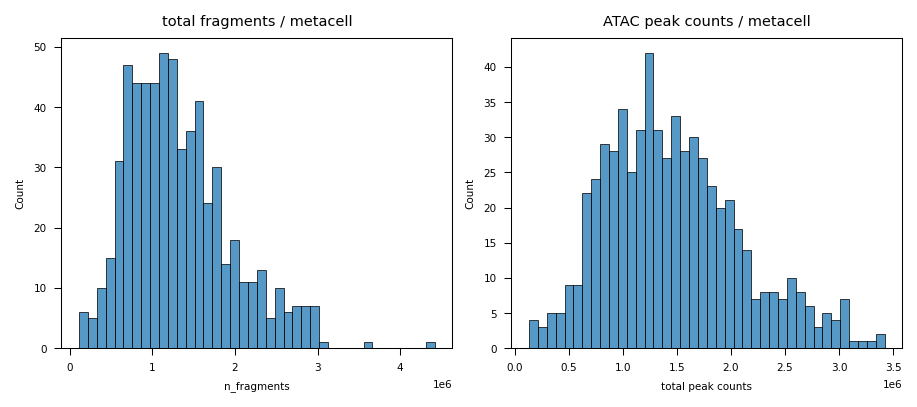

In [6]:
frag_depth = meta_adata.obs["n_fragments"].to_numpy()
peak_depth = np.asarray(peak_adata.X.sum(axis=1)).ravel()

fig, axes = plt.subplots(figsize=(6, 2.6), ncols=2, dpi=150, constrained_layout=True)
sns.histplot(frag_depth, bins=40, ax=axes[0])
axes[0].set(title="total fragments / metacell", xlabel="n_fragments")
sns.histplot(peak_depth, bins=40, ax=axes[1])
axes[1].set(title="ATAC peak counts / metacell", xlabel="total peak counts")

print("metadata:", meta_adata.shape, "| peak:", peak_adata.shape, "| gene:", gene_adata.shape)
assert list(peak_adata.obs_names) == list(gene_adata.obs_names)

---

You now have three metacell AnnData files for ChromiumPBMC — `metacell.metadata.h5ad`,
`metacell.peak_count.h5ad`, and `metacell.gene_count.h5ad` — summarizing the dataset at metacell
resolution. The next page, [Parquet dataset](04_parquet_dataset.ipynb), goes the other direction:
it sums the raw fragment insertions into a **base-resolution** coverage store that Bolero trains on.